# **Lab 6: Lakeflow Spark Declarative Pipelines**

Lecturer: `Sirasit Lochanachit`


Course: `06026213 Big Data Systems`

Term: `02/2025`

Lab materials prepared by `Sasithorn (TA) - 2025`

# Example 1: Simple ETL pipeline with Lakeflow Spark Declarative Pipelines

ในตัวอย่างนี้จะแสดงการสร้างและ deploy ETL (extract, transform, load) pipeline สำหรับ data orchestration โดยใช้ Lakeflow Spark Declarative Pipelines และ Auto Loader
- ETL Pipeline คือการทำขั้นตอนการอ่านข้อมูลจาก source systems แล้วทำการ transform ข้อมูลตาม requirement เช่น การทำ data quality checks และการลบข้อมูลซ้ำ จากนั้นทำการเขียนข้อมูลลงบน target system เช่น data warehouse หรือ data lake

ดังนั้นตัวอย่างนี้จะสาธิตการใช้ pipeline และ Auto Loader ในการ
- ingest raw source data
- transform raw source data และ write transformed data ไปเป็น 3 materialized views
- query the transformed data
- automate the ETL pipeline with a Databricks Job

## About the dataset

Dataset ที่เราใช้จะเป็น subset ของ [Million Song Dataset](http://millionsongdataset.com/) ซึ่งเป็น collection ของ features และ metadata ของ contemporary music tracks 
- Dataset นี้มีอยู่ใน sample datasets บน Databricks workspace

# Step 1: Create a pipeline

1. ในหน้าหลัก คลิกปุ่ม `+ New` ที่ sidebar → `ETL Pipeline`

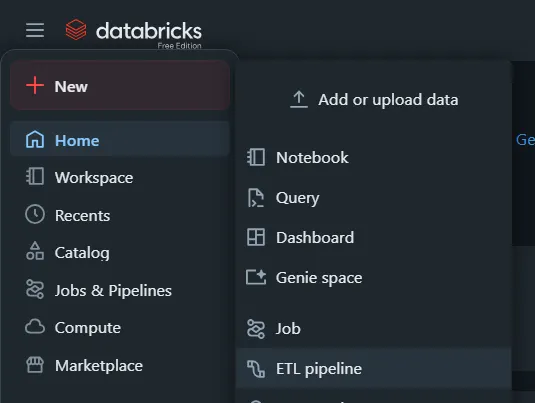

2. ตั้งชื่อ Pipeline
3. ใน Dropdown ให้เลือก catalog กับ schema สำหรับ data ที่จะ generate
    - เฉพาะตัวอย่างนี้สามารถใช้ workspace.default ได้

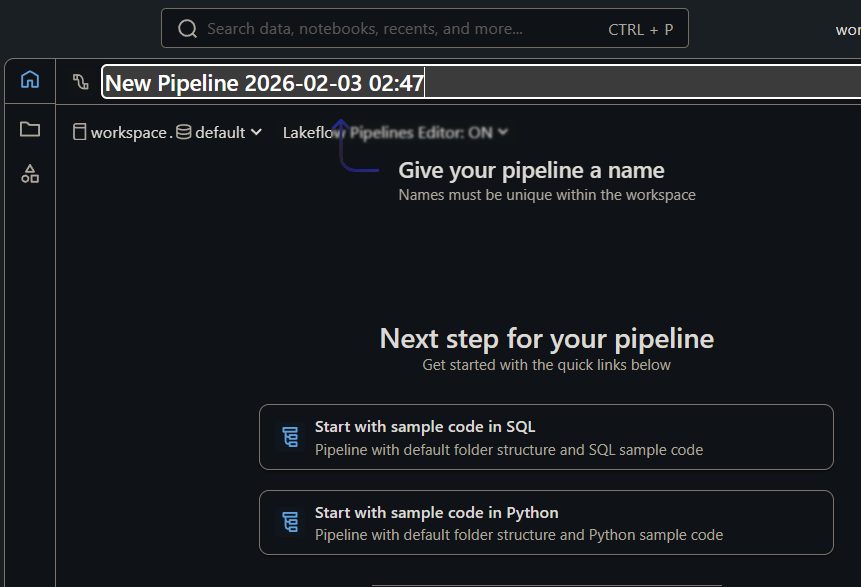

4. ตรง advanced options ให้คลิก Start with an empty file
5. ในหน้า Select a folder for your code ในช่อง folder path ด้านซ้าย ให้เลือก location สำหรับ pipeline folder หรือสามารถใช้ค่า default (folder ชื่อเรา)
6. เลือก Python หรือ SQL สำหรับ source file อันแรกของเราได้เลย ในที่นี้เราใช้ Python
    - pipeline สามารถใช้ได้หลายภาษา แต่ว่าในแต่ละไฟล์จะต้องเป็นภาษาเดียวเท่านั้น
7. คลิกปุ่ม Select

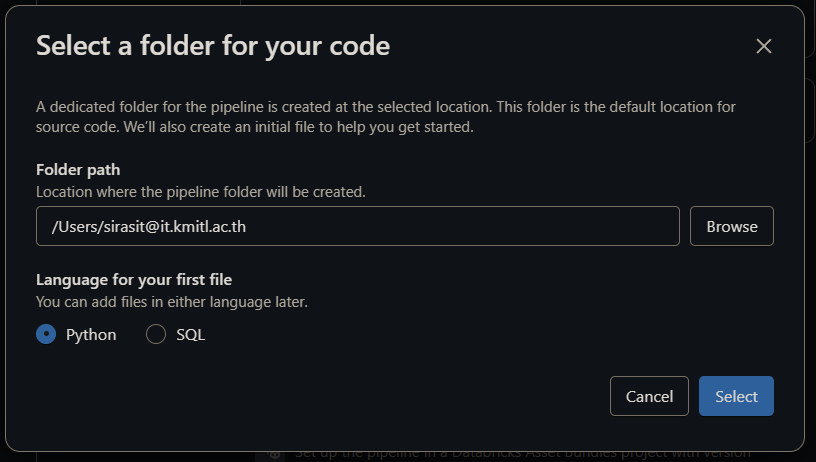

# Step 2: Develop your pipeline logic

ในขั้นตอนนี้เราจะใช้ lakeflow pipeline editor (ซึ่งก็คือในหน้า pipeline ที่เราเข้ามา) ในการ develop และ validate source code สำหรับ pipeline

Code ตัวอย่างด้านล่างจะใช้ Auto Loader สำหรับ incremental data ingestion ซึ่งก็คือการ detect และ process new file โดยอัตโนมัติเมื่อมี file ใหม่เข้ามาใน cloud object storage

ตอนที่สร้าง pipeline ครั้งแรกจะมี source code file เปล่าถูกสร้างขึ้นมา ซึ่งไฟล์นี้อยู่ใน transformation folder ของ pipeline
- โดยทั่วไป ไฟล์ประเภท .py และ .sql จะอยู่ใน transformation folder

1. Copy and paste code ด้านล่างนี้ไปยัง source file ของเรา (my_transformation.py)

In [ ]:
# Import modules
from pyspark import pipelines as dp
from pyspark.sql.functions import *
from pyspark.sql.types import DoubleType, IntegerType, StringType, StructType, StructField

# Define the path to the source data
file_path = f"/databricks-datasets/songs/data-001/"

# Define a streaming table to ingest data from a volume
schema = StructType(
  [
    StructField("artist_id", StringType(), True),
    StructField("artist_lat", DoubleType(), True),
    StructField("artist_long", DoubleType(), True),
    StructField("artist_location", StringType(), True),
    StructField("artist_name", StringType(), True),
    StructField("duration", DoubleType(), True),
    StructField("end_of_fade_in", DoubleType(), True),
    StructField("key", IntegerType(), True),
    StructField("key_confidence", DoubleType(), True),
    StructField("loudness", DoubleType(), True),
    StructField("release", StringType(), True),
    StructField("song_hotnes", DoubleType(), True),
    StructField("song_id", StringType(), True),
    StructField("start_of_fade_out", DoubleType(), True),
    StructField("tempo", DoubleType(), True),
    StructField("time_signature", DoubleType(), True),
    StructField("time_signature_confidence", DoubleType(), True),
    StructField("title", StringType(), True),
    StructField("year", IntegerType(), True),
    StructField("partial_sequence", IntegerType(), True)
  ]
)

@dp.materialized_view(
  comment="Raw data from a subset of the Million Song Dataset; a collection of features and metadata for contemporary music tracks."
)
def songs_raw():
  return (spark.read
    .format("csv")
    .schema(schema)
    .option("sep","\t")
    .load(file_path))

# Define a materialized view that validates data and renames a column
@dp.materialized_view(
  comment="Million Song Dataset with data cleaned and prepared for analysis."
)
@dp.expect("valid_artist_name", "artist_name IS NOT NULL")
@dp.expect("valid_title", "song_title IS NOT NULL")
@dp.expect("valid_duration", "duration > 0")
def songs_prepared():
  return (
    spark.read.table("songs_raw")
      .withColumnRenamed("title", "song_title")
      .select("artist_id", "artist_name", "duration", "release", "tempo", "time_signature", "song_title", "year")
  )

# Define a materialized view that has a filtered, aggregated, and sorted view of the data
@dp.materialized_view(
  comment="A table summarizing counts of songs released by the artists who released the most songs each year."
)
def top_artists_by_year():
  return (
    spark.read.table("songs_prepared")
      .filter(expr("year > 0"))
      .groupBy("artist_name", "year")
      .count().withColumnRenamed("count", "total_number_of_songs")
      .sort(desc("total_number_of_songs"), desc("year"))
  )

## ทดสอบ

In [ ]:
@dp.table(
  comment="Raw data from a subset of the Million Song Dataset; a collection of features and metadata for contemporary music tracks."
)
def songs_raw():
  return (spark.readStream
    .format("cloudFiles")
    .schema(schema)
    .option("cloudFiles.format", "csv")
    .option("sep","\t")
    .load(file_path))

Code นี้ประกอบด้วย 3 function หรือ 3 query ซึ่งสามารถแยกเก็บเป็นไฟล์แยกได้

2. คลิก `Run file` หรือ `Run pipeline` เพื่อเริ่มการ update สำหรับ pipeline ที่เชื่อมอยู่
- เมื่อการ update เสร็จสิ้น ตัว editor จะมีการ update ข้อมูลเกี่ยวกับ pipeline
- Pipeline graph (DAG) ใน sidebar ด้านขวา แสดงตาราง 3 ตารางคือ `songs_raw`, `songs_prepared`, และ `top_artists_by_year`
- รายละเอียดของตารางที่สร้างขึ้นมาจะแสดงอยู่ในหน้าต่างด้านล่าง

# Step 3: Explore the datasets created by your pipeline

ในขั้นตอนนี้จะทำการส่ง ad-hoc query บนข้อมูลที่ถูก process แล้วใน ETL pipeline เพื่อวิเคราะห์ข้อมูลเพลงใน Databricks SQL Editor โดย query เหล่านี้จะใช้ข้อมูล records ที่พึ่งถูกสร้างมาในขั้นตอนที่แล้ว

## 1. Run query ที่ค้นหา artists ที่ release เพลงมากที่สุดในแต่ละปีโดยเริ่มตั้งแต่ปี 1990

1. ใน pipeline assets browser ตรงแถบด้านซ้าย ที่มี folder pipeline ของเรา ให้คลิก + จากนั้นคลิก `Exploration`
2. ตั้งชื่อ แล้วเลือก notebook ให้เป็น SQL, พอเราสร้างไฟล์มาแล้ว ไฟล์ที่สร้างใน explorations folder จะไม่ถูก run เป็นส่วนหนึ่งของ pipeline โดย default

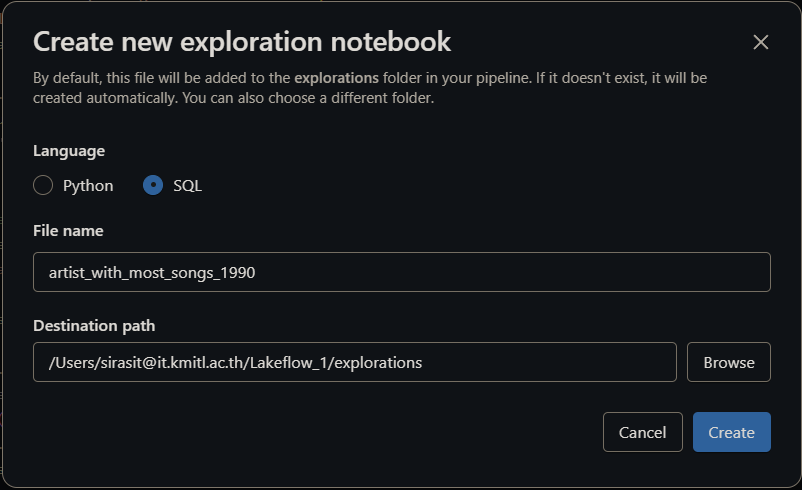

3. Copy code ข้างล่างนี้ไปยัง file SQL Notebook ที่พึ่งสร้างขึ้นมา
    - อย่าลืมปรับ path ให้ถูกต้องตามที่เรามี

In [ ]:
-- Which artists released the most songs each year in 1990 or later?
SELECT artist_name, total_number_of_songs, year
  -- replace with the catalog/schema you are using:
  FROM workspace.default.top_artists_by_year
  WHERE year >= 1990
  ORDER BY total_number_of_songs DESC, year DESC;

4. คลิกปุ่ม  หรือกด Shift + Enter เพื่อ run query

## 2. Run query ที่ค้นหาเพลงที่มี 4/4 beat และ tempo ระหว่าง 100 และ 140

Copy และเพิ่ม code ข้างล่างนี้ไปยัง file SQL

In [ ]:
-- Find songs with a 4/4 beat and danceable tempo
SELECT artist_name, song_title, tempo
  -- replace with the catalog/schema you are using:
  FROM workspace.default.songs_prepared
  WHERE time_signature = 4 AND tempo between 100 and 140;

กด Shift + Enter เพื่อ run query

# Step 4: Create a job to run the pipeline

สร้าง workflow ที่ automate ทั้ง data ingestion, processing, analysis ไปตาม step โดยใช้ Databricks job ซึ่งจะรันตามตารางเวลาที่เรากำหนดไว้

1. บนสุดของ editor จะมีปุ่ม `Schedule`
2. หากมี `Schedule` dialog โผล่ขึ้นมาให้เลือก `Add Schedule` หากไม่มีจะเป็น `New Schedule` dialog ที่โผล่ขึ้นมา
3. เลือก job ที่ต้องการ run pipeline ตาม schedule
4. ตั้งชื่อ schedule
5. โดย default นั้น schedule จะถูกตั้งไว้ให้ run 1 ครั้งต่อวัน ซึ่งเราสามารถกำหนดเองได้ โดยไปที่ `Advanced`
6. เลือกปุ่ม Create เพื่อสร้าง job ขึ้นมา

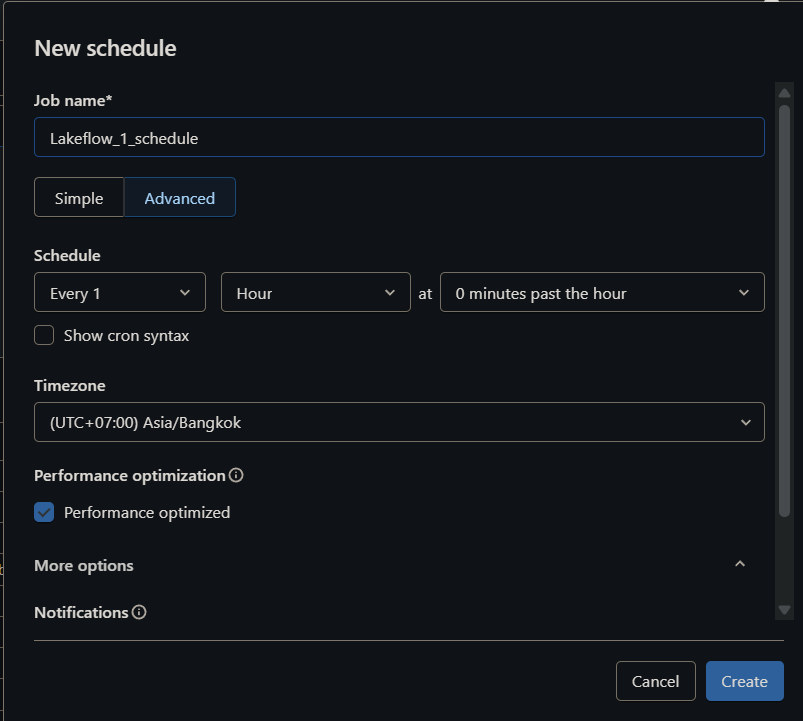

ณ ตอนนี้ job ก็จะทำการ run ตามเวลาที่กำหนดเพื่อให้ pipeline มีข้อมูลที่ update ให้เป็นปัจจุบัน

---

# Example 2: Create pipeline using the Lakeflow Pipelines Editor

ในตัวอย่างนี้จะสร้าง pipeline โดยใช้ SDP สำหรับ data orchestration และใช้ Auto Loader โดยการใช้ Lakeflow Pipelines Editor 
- สาธิต pipeline ที่ทำความสะอาดข้อมูลและสร้าง query ในการค้นหา top 100 users
- สร้าง pipeline ใหม่โดนใช้ default folder structure และใช้ sample files
- นิยาม data quality constraints โดยใช้ expectations
- ใช้ editor ในการ extend pipeline ด้วย transformation เพื่อทำการ analyse data


## Step 1: Create a pipeline

ในขั้นตอนนี้เป็นการสร้าง pipeline โดยใช้ default folder structure และใช้ sample data source `wanderbricks` และ table `users`

1. ในหน้า Databricks workspace ให้คลิก `+ New` ที่ sidebar → `ETL Pipeline`
2. คลิก header เพื่อตั้งชื่อ pipeline
3. ใต้ชื่อ pipeline กำหนดเป็น default catalog และ schema (ไม่ต้องทำอะไร)
4. เลือก `Start with sample code in Python`
    - สามารถเพิ่ม code ภาษาอื่น ๆ ได้ในภายหลัง ขั้นตอนนี้เป็นเพียงการสร้าง default folder structure ที่มีตัวอย่าง code มาให้

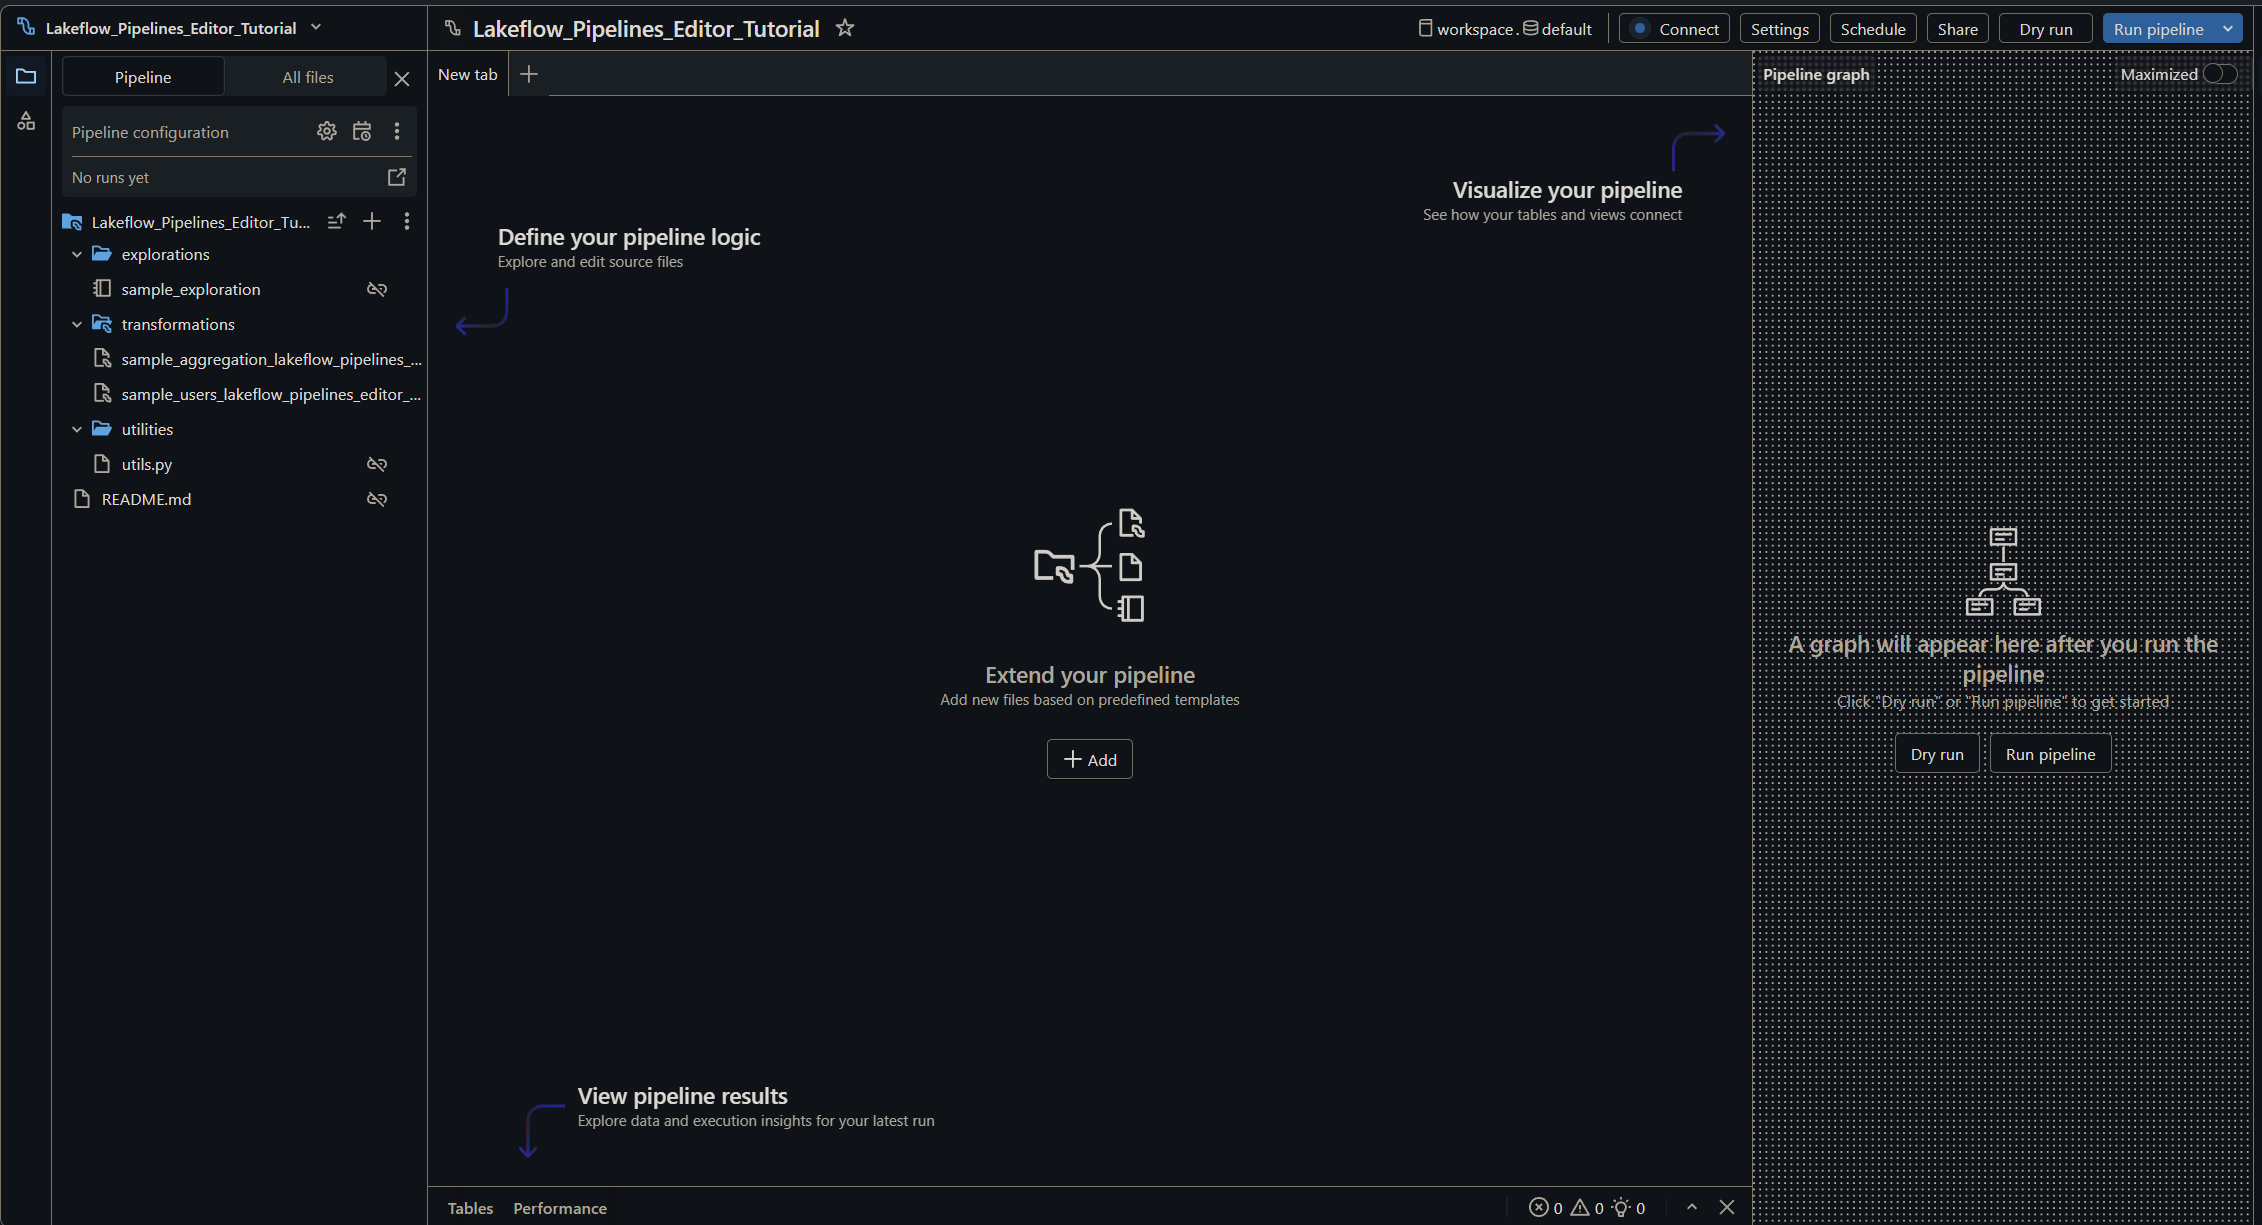

5. สามารถดู code ตัวอย่างในหน้าต่าง pipeline asset browser ทางซ้ายมือได้
    - ใน folder `transformations` จะมี 2 file ที่ไว้สร้าง pipeline dataset แต่ละอัน
    - ใน folder `explorations` จะมี jupyter notebook ที่มีตัวอย่าง code ใช้ในการดู output ของ pipeline

เนื่องจาก output dataset ยังไม่ได้ถูกสร้าง และ Pipeline graph ด้านขวามือก็โล่งอยู่

6. คลิก `Run file` เช่น file sample_users_lakeflow_pipelines_editor.py เพื่อทำการดู preview ของ transformation 1 อัน
7. คลิก `Run pipeline` ตรงมุมบนขวา เพื่อทำการ run ทุก transformation ใน pipeline และดูกราฟ
    - หลังจาก run เสร็จสิ้น ในหน้าต่างด้านล่างจะแสดง table 2 ตารางที่ถูกสร้างขึ้นมาคือ `sample_users_<pipeline-name>` และ `sample_aggregation_<pipeline-name>`
    - Pipeline graph ในด้านขวาแสดงให้เห็นว่า `sample_users` เป็น data source ของ `sample_aggregation`

Question: 
1. มีข้อมูลกี่แถวในตาราง `sample_users_<pipeline-name>`
2. User มีกี่ type และจำนวน email ของแต่ละ user type มีจำนวนเท่าไร

## Step 2: Apply Data Quality Checks

ในขั้นตอนนี้จะทำการเพิ่ม data quality check ให้กับ `sample_users` table โดยการใช้ pipeline expectations 

ในกรณีตัวอย่างนี้จะทำการลบ user record ที่ไม่มี email address และ output table ที่ clean แล้วอยู่ใน `users_cleaned` table

1. ในหน้าต่าง pipeline asset browser ให้คลิก + แล้วตามด้วย **Transformation**
2. ในหน้าต่าง **Create new transformation file** ให้เลือกตามนี้:
    - เลือก Python หรือ SQL ก็ได้
    - ตั้งชื่อ file เช่น `users_cleaned`
    - สำหรับ **Destination path** ให้ปล่อยเป็น default
    - สำหรับ **Dataset type** เลือก **None selected** หรือ เลือก **Materialized view**
        - หากเลือก Materialized view จะมีการสร้างตัวอย่าง code มาให้
3. ในไฟล์ใหม่ ให้ copy paste code ด้านล่างนี้ (ใช้ SQL หรือ Python ขึ้นอยู่กับขั้นตอนที่ 2) และแทนที่ <pipeline_name> ด้วยชื่อ pipeline ที่กำหนดไว้ตอนแรก
4. คลิก **Run pipeline** เพื่อ update pipeline จากนั้นสังเกต **Pipeline Graph** ว่ามีทั้งหมด 3 table


Question: มีข้อมูลกี่แถวที่ถูก Drop

### SQL

```SQL
-- Drop all rows that do not have an email address

CREATE MATERIALIZED VIEW users_cleaned
(
  CONSTRAINT non_null_email EXPECT (email IS NOT NULL) ON VIOLATION DROP ROW
) AS
SELECT *
FROM sample_users_<pipeline-name>;
```

### Python

```python
from pyspark import pipelines as dp

# Drop all rows that do not have an email address

@dp.table
@dp.expect_or_drop("no null emails", "email IS NOT NULL")
def users_cleaned():
    return (
        spark.read.table("sample_users_<pipeline_name>")
    )
```

## Step 3: Analyze Top Users

ในขั้นตอนนี้จะทำการดึงข้อมูล top 100 users จากจำนวน bookings ซึ่งจะต้อง join table `wanderbricks.bookings` เข้ากับ `users_cleaned` materialized view.

1. ในหน้าต่าง pipeline asset browser ให้คลิก + แล้วตามด้วย **Transformation**
2. ในหน้าต่าง **Create new transformation file** ให้เลือกตามนี้:
    - เลือก Python หรือ SQL ก็ได้
    - ตั้งชื่อ file เช่น `users_and_bookings`
    - สำหรับ **Destination path** ให้ปล่อยเป็น default
    - สำหรับ **Dataset type** เลือก **None selected**
3. ในไฟล์ใหม่ ให้ copy paste code ด้านล่างนี้ (ใช้ SQL หรือ Python ขึ้นอยู่กับขั้นตอนที่ 2)
4. คลิก **Run pipeline** เพื่อ update dataset จากนั้นสังเกต **Pipeline Graph** ว่ามีทั้งหมด 4 table

Question: User ใดมีจำนวน booking สูงสุด

### SQL

```SQL
-- Get the top 100 users by number of bookings

CREATE OR REFRESH MATERIALIZED VIEW users_and_bookings AS
SELECT u.name AS name, COUNT(b.booking_id) AS booking_count
FROM users_cleaned u
JOIN samples.wanderbricks.bookings b ON u.user_id = b.user_id
GROUP BY u.name
ORDER BY booking_count DESC
LIMIT 100;
```

### Python

```python
from pyspark import pipelines as dp
from pyspark.sql.functions import col, count, desc

# Get the top 100 users by number of bookings

@dp.table
def users_and_bookings():
    return (
        spark.read.table("users_cleaned")
        .join(spark.read.table("samples.wanderbricks.bookings"), "user_id")
        .groupBy(col("name"))
        .agg(count("booking_id").alias("booking_count"))
        .orderBy(desc("booking_count"))
        .limit(100)
    )
```

---

## Pipeline Graph (Final)

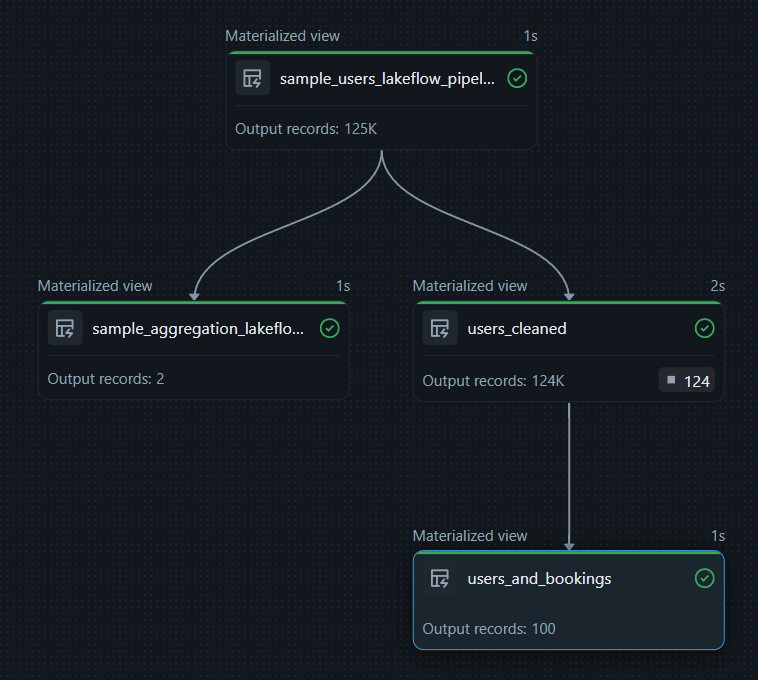

---